In [1]:
from utils_task2 import RedditLinkDataset

dataset = RedditLinkDataset(path="Reddit")
train_loader, val_loader, test_loader = dataset.get_link_loaders(batch_size=512)

Caricamento del macro-grafo originale di Reddit...
Grafo originale: 232965 nodi, 114615892 archi

=== SOTTOGRAFO PER TASK 2 ===
Nodi nel sottografo: 11308
Archi nel sottografo: 3591622

--- STATISTICHE STRUTTURALI DEL GRAFO RIDOTTO ---
Archi positivi (Supervisione) in Train: 1257068
Coppie totali (Pos+Neg) in Val: 359162
Coppie totali (Pos+Neg) in Test: 718324


In [2]:
#iperparametri
lr = 0.5e-5
num_epochs = 10

Tentativo GCN

In [3]:
import torch
from utils_task2 import GCNLinkPredictor
from utils_task2 import train_loop, evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nInizio Task 2 (Link Prediction) su dispositivo: {device}")

num_features = dataset.dataset.num_features
model = GCNLinkPredictor(in_channels=num_features, hidden_channels=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
# non mettiamo pesi perchè le classi sono blianciate per creazione, dato che il neg_sampling_ratio è stato impostato a 1.0
loss_fn = torch.nn.BCEWithLogitsLoss()

scaler = torch.amp.GradScaler('cuda')

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path="best_model_task2_GCN.pth",
    scaler=scaler,
)




Inizio Task 2 (Link Prediction) su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO LINK PREDICTION ---


Epoca: 01/10 |Loss Train: 0.5095 | Loss Val: 0.4765 | Val AUC-ROC: 0.9198 |Val AP: 0.8646 |Val Balanced Acc: 0.8567 |Val F1: 0.8740
--> Modello salvato con Loss Val Migliore: 0.4765


Epoca: 02/10 |Loss Train: 0.4700 | Loss Val: 0.4693 | Val AUC-ROC: 0.9291 |Val AP: 0.8870 |Val Balanced Acc: 0.8590 |Val F1: 0.8758
--> Modello salvato con Loss Val Migliore: 0.4693


Epoca: 03/10 |Loss Train: 0.4696 | Loss Val: 0.4658 | Val AUC-ROC: 0.9309 |Val AP: 0.8933 |Val Balanced Acc: 0.8606 |Val F1: 0.8770
--> Modello salvato con Loss Val Migliore: 0.4658


Epoca: 04/10 |Loss Train: 0.4693 | Loss Val: 0.4636 | Val AUC-ROC: 0.9329 |Val AP: 0.8953 |Val Balanced Acc: 0.8613 |Val F1: 0.8775
--> Modello salvato con Loss Val Migliore: 0.4636


...

Epoca: 06/10 |Loss Train: 0.4678 | Loss Val: 0.4628 | Val AUC-ROC: 0.9336 |Val AP: 0.8980 |Val Balanced Acc: 0.8628 |Val F1: 0.8786
--> Modello salvato con Loss Val Migliore: 0.4628


Epoca: 07/10 |Loss Train: 0.4681 | Loss Val: 0.4610 | Val AUC-ROC: 0.9347 |Val AP: 0.8979 |Val Balanced Acc: 0.8643 |Val F1: 0.8798
--> Modello salvato con Loss Val Migliore: 0.4610


Epoca: 08/10 |Loss Train: 0.4674 | Loss Val: 0.4618 | Val AUC-ROC: 0.9350 |Val AP: 0.8993 |Val Balanced Acc: 0.8633 |Val F1: 0.8790
--> Nessun miglioramento. Contatore di pazienza: 1/5


Epoca: 09/10 |Loss Train: 0.4674 | Loss Val: 0.4607 | Val AUC-ROC: 0.9335 |Val AP: 0.8986 |Val Balanced Acc: 0.8643 |Val F1: 0.8798
--> Modello salvato con Loss Val Migliore: 0.4607


Epoca: 10/10 |Loss Train: 0.4672 | Loss Val: 0.4606 | Val AUC-ROC: 0.9334 |Val AP: 0.8999 |Val Balanced Acc: 0.8636 |Val F1: 0.8793
--> Modello salvato con Loss Val Migliore: 0.4606


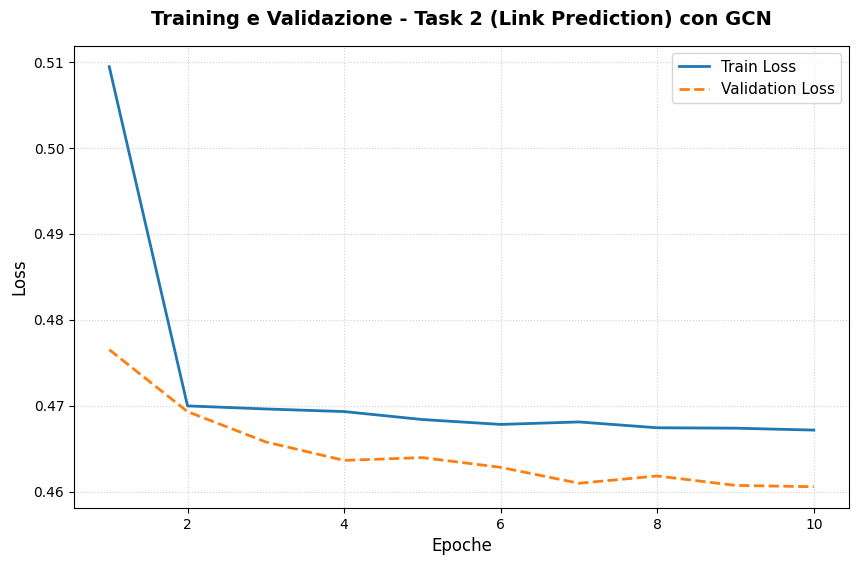

In [4]:
from utils_task1 import plot_history
plot_history(history, title="Training e Validazione - Task 2 (Link Prediction) con GCN")


--- VERIFICA FINALE SUL TEST SET ARCHI ---



RISULTATI GLOBALI TASK 2 GCN
-> Test Loss: 0.4610
-> Area Under the ROC Curve (AUC-ROC): 0.9330
-> Average Precision (AP Score): 0.8985
-> Balanced Accuracy: 0.8648
-> F1 Score: 0.8802


[]

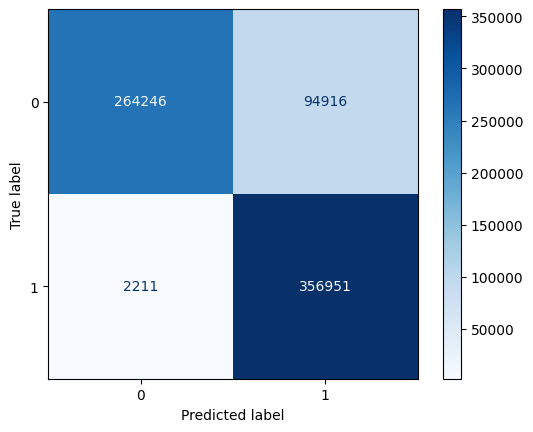

In [5]:
# Verifica finale sul test set 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- VERIFICA FINALE SUL TEST SET ARCHI ---")
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"\nRISULTATI GLOBALI TASK 2 GCN")
print(f"-> Test Loss: {test_metrics['val_loss']:.4f}")
print(f"-> Area Under the ROC Curve (AUC-ROC): {test_metrics['roc_auc']:.4f}")
print(f"-> Average Precision (AP Score): {test_metrics['average_precision']:.4f}")
print(f"-> Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"-> F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

[]

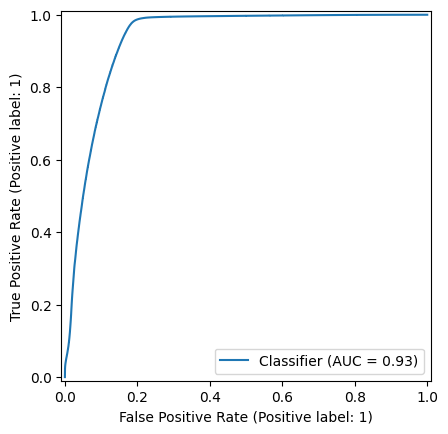

In [6]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()

Tentativo SAGEConv

In [7]:
import torch
from utils_task2 import SAGEConvLinkPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nInizio Task 2 (Link Prediction) su dispositivo: {device}")

num_features = dataset.dataset.num_features
model = SAGEConvLinkPredictor(in_channels=num_features, hidden_channels=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
# non mettiamo pesi perchè le classi sono blianciate per creazione, dato che il neg_sampling_ratio è stato impostato a 1.0
loss_fn = torch.nn.BCEWithLogitsLoss()

scaler = torch.amp.GradScaler('cuda')

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path="best_model_task2_SAGE.pth",
    scaler=scaler,
)



Inizio Task 2 (Link Prediction) su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO LINK PREDICTION ---


Epoca: 01/10 |Loss Train: 0.5052 | Loss Val: 0.4454 | Val AUC-ROC: 0.9494 |Val AP: 0.9383 |Val Balanced Acc: 0.8533 |Val F1: 0.8714
--> Modello salvato con Loss Val Migliore: 0.4454


Epoca: 02/10 |Loss Train: 0.4659 | Loss Val: 0.4365 | Val AUC-ROC: 0.9558 |Val AP: 0.9476 |Val Balanced Acc: 0.8597 |Val F1: 0.8762
--> Modello salvato con Loss Val Migliore: 0.4365


Epoca: 03/10 |Loss Train: 0.4614 | Loss Val: 0.4336 | Val AUC-ROC: 0.9580 |Val AP: 0.9505 |Val Balanced Acc: 0.8619 |Val F1: 0.8780
--> Modello salvato con Loss Val Migliore: 0.4336


Epoca: 04/10 |Loss Train: 0.4600 | Loss Val: 0.4315 | Val AUC-ROC: 0.9594 |Val AP: 0.9527 |Val Balanced Acc: 0.8635 |Val F1: 0.8792
--> Modello salvato con Loss Val Migliore: 0.4315


KeyboardInterrupt: 

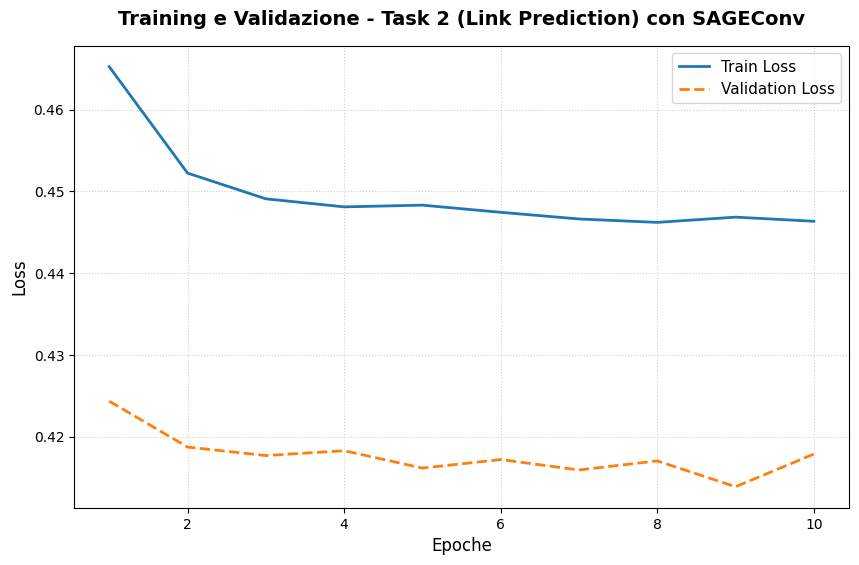

In [ ]:
from utils_task1 import plot_history
plot_history(history, title="Training e Validazione - Task 2 (Link Prediction) con SAGEConv")


--- VERIFICA FINALE SUL TEST SET ARCHI ---



RISULTATI GLOBALI TASK 2 SAGEConv
-> Test Loss: 0.4186
-> Area Under the ROC Curve (AUC-ROC): 0.9713
-> Average Precision (AP Score): 0.9673
-> Balanced Accuracy: 0.8590
-> F1 Score: 0.8759


[]

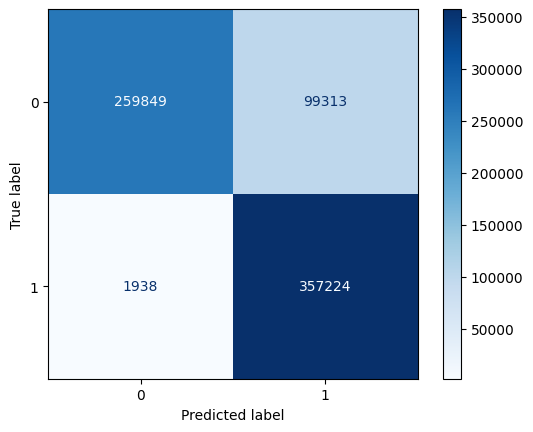

In [ ]:
# Verifica finale sul test set 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- VERIFICA FINALE SUL TEST SET ARCHI ---")
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"\nRISULTATI GLOBALI TASK 2 SAGEConv")
print(f"-> Test Loss: {test_metrics['val_loss']:.4f}")
print(f"-> Area Under the ROC Curve (AUC-ROC): {test_metrics['roc_auc']:.4f}")
print(f"-> Average Precision (AP Score): {test_metrics['average_precision']:.4f}")
print(f"-> Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"-> F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

[]

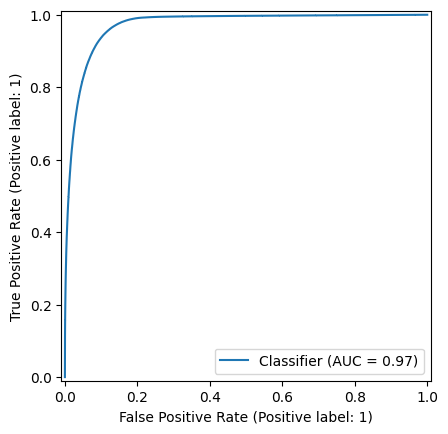

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()

Tentativo GAT

In [ ]:
import torch
from utils_task2 import GATLinkPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nInizio Task 2 (Link Prediction) su dispositivo: {device}")

num_features = dataset.dataset.num_features
model = GATLinkPredictor(in_channels=num_features, hidden_channels=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
# non mettiamo pesi perchè le classi sono blianciate per creazione, dato che il neg_sampling_ratio è stato impostato a 1.0
loss_fn = torch.nn.BCEWithLogitsLoss()

scaler = torch.amp.GradScaler('cuda')

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path="best_model_task2_GAT.pth",
    scaler=scaler,
)



Inizio Task 2 (Link Prediction) su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO LINK PREDICTION ---


Epoca: 01/10 |Loss Train: 0.4768 | Loss Val: 0.4387 | Val AUC-ROC: 0.9537 |Val AP: 0.9443 |Val Balanced Acc: 0.8644 |Val F1: 0.8799
--> Modello salvato con Loss Val Migliore: 0.4387


Epoca: 02/10 |Loss Train: 0.4624 | Loss Val: 0.4335 | Val AUC-ROC: 0.9568 |Val AP: 0.9489 |Val Balanced Acc: 0.8673 |Val F1: 0.8821
--> Modello salvato con Loss Val Migliore: 0.4335


Epoca: 03/10 |Loss Train: 0.4603 | Loss Val: 0.4342 | Val AUC-ROC: 0.9573 |Val AP: 0.9498 |Val Balanced Acc: 0.8636 |Val F1: 0.8791
--> Nessun miglioramento. Contatore di pazienza: 1/5


Epoca: 04/10 |Loss Train: 0.4595 | Loss Val: 0.4347 | Val AUC-ROC: 0.9585 |Val AP: 0.9512 |Val Balanced Acc: 0.8610 |Val F1: 0.8772
--> Nessun miglioramento. Contatore di pazienza: 2/5


...

Epoca: 06/10 |Loss Train: 0.4580 | Loss Val: 0.4300 | Val AUC-ROC: 0.9593 |Val AP: 0.9509 |Val Balanced Acc: 0.8643 |Val F1: 0.8798
--> Modello salvato con Loss Val Migliore: 0.4300


Epoca: 07/10 |Loss Train: 0.4574 | Loss Val: 0.4308 | Val AUC-ROC: 0.9602 |Val AP: 0.9536 |Val Balanced Acc: 0.8607 |Val F1: 0.8769
--> Nessun miglioramento. Contatore di pazienza: 1/5


Epoca: 08/10 |Loss Train: 0.4568 | Loss Val: 0.4324 | Val AUC-ROC: 0.9600 |Val AP: 0.9528 |Val Balanced Acc: 0.8585 |Val F1: 0.8752
--> Nessun miglioramento. Contatore di pazienza: 2/5


Epoca: 09/10 |Loss Train: 0.4571 | Loss Val: 0.4287 | Val AUC-ROC: 0.9604 |Val AP: 0.9533 |Val Balanced Acc: 0.8658 |Val F1: 0.8809
--> Modello salvato con Loss Val Migliore: 0.4287


Epoca: 10/10 |Loss Train: 0.4562 | Loss Val: 0.4299 | Val AUC-ROC: 0.9609 |Val AP: 0.9539 |Val Balanced Acc: 0.8636 |Val F1: 0.8792
--> Nessun miglioramento. Contatore di pazienza: 1/5


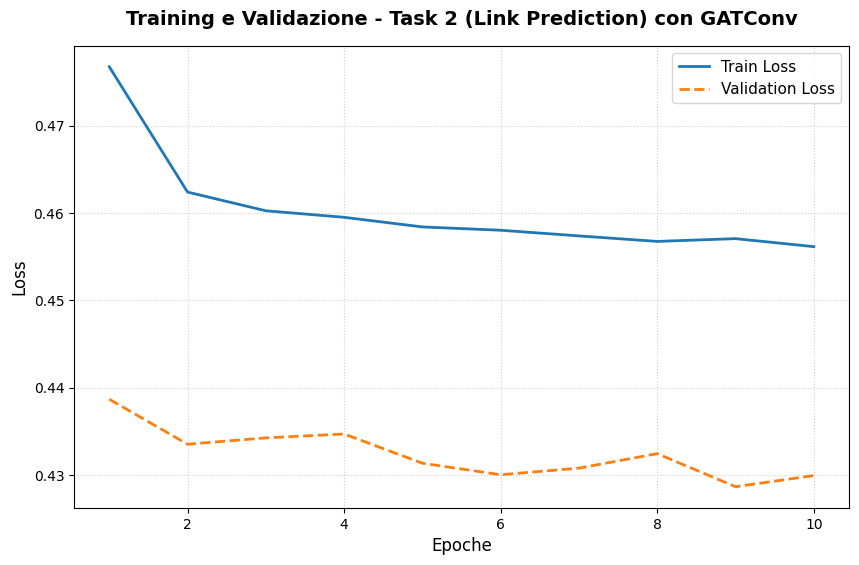

In [ ]:
from utils_task1 import plot_history
plot_history(history, title="Training e Validazione - Task 2 (Link Prediction) con GATConv")


--- VERIFICA FINALE SUL TEST SET ARCHI ---



RISULTATI GLOBALI TASK 2 GATConv
-> Test Loss: 0.4302
-> Area Under the ROC Curve (AUC-ROC): 0.9607
-> Average Precision (AP Score): 0.9537
-> Balanced Accuracy: 0.8643
-> F1 Score: 0.8798


[]

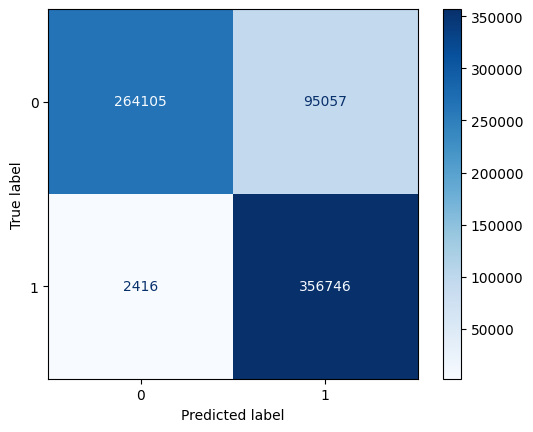

In [ ]:
# Verifica finale sul test set 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- VERIFICA FINALE SUL TEST SET ARCHI ---")
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"\nRISULTATI GLOBALI TASK 2 GATConv")
print(f"-> Test Loss: {test_metrics['val_loss']:.4f}")
print(f"-> Area Under the ROC Curve (AUC-ROC): {test_metrics['roc_auc']:.4f}")
print(f"-> Average Precision (AP Score): {test_metrics['average_precision']:.4f}")
print(f"-> Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"-> F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

[]

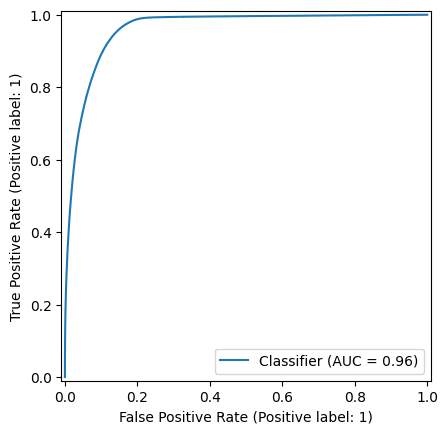

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()